# UNIVERSIDAD NACIONAL DE SAN ANTONIO ABAD DEL CUSCO
## FACULTAD DE INGENIERÍA ELÉCTRICA, ELECTRÓNICA, INFORMÁTICA Y MECÁNICA
### ESCUELA PROFESIONAL DE INGENIERÍA INFORMÁTICA Y DE SISTEMAS

---

# INFORME DE LABORATORIO N.º 04
## “MONTÍCULOS DE FIBONACCI Y ANÁLISIS AMORTIZADO”

* **Asignatura:** ALGORITMOS AVANZADOS
* **Semestre Académico:** 2026-II
* **Docente:** Ing. Héctor Eduardo Ugarte Rojas
* **Equipo:** GRUPO 5
* **Integrantes:**
  * Choquenaira Quispe, Noe Franklin — `133962`
  * Porroa Sivana, Yeni Ruth — `120893`
  * Quispe Rimachi, Romario — `164257`
  * Yaranga Achahui, Aldo — `103179`
* **Lugar y Fecha:** Cusco-Perú - 2026

---

### Guía de Uso del Cuaderno Interactivo

1. **Ejecución completa:** En Google Colab o Jupyter, seleccionar **`Entorno de ejecución → Ejecutar todas`** (`Ctrl + F9`). El tiempo estimado de ejecución es de **30 a 60 segundos**.
2. **Descarga de evidencias:** La última celda empaqueta los resultados en `resultados_lab04.zip` y dispara su descarga automática.
3. **Reproducibilidad:** La semilla fija `SEMILLA_GLOBAL = 2026` garantiza que las instancias, grafos y secuencias de operaciones son deterministas en cualquier entorno.

### Estructura del Cuaderno

| Sección | Contenido |
|:---:|---|
| **1** | **Trabajo Preparatorio Obligatorio:** Respuestas analíticas a las preguntas de la Guía 04. |
| **2** | **Configuración del Entorno:** Inicialización determinista y creación de directorios. |
| **3** | **Ejercicios Resueltos:** Potencial contable, consolidación didáctica y `HeapqPriorityQueue` con actualización perezosa. |
| **4** | **Propuesto 1 (Fibonacci Heap):** Implementación completa de `FibonacciNode` y `FibonacciHeap` con método `validate()` para 8 invariantes. |
| **5** | **Batería de Pruebas de Invariantes:** Validación exhaustiva de casos frontera, cortes en cascada de $\ge 2$ niveles y 250 operaciones aleatorias. |
| **6** | **Propuesto 1 (Análisis Gráfico):** Evolución del potencial $\Phi(H)$ y balance contable amortizado. |
| **7** | **Propuesto 2 - Escenario A:** Operaciones básicas ($n \in \{1k, 5k, 10k, 25k\}$) con 10 repeticiones estadísticas. |
| **8** | **Propuesto 2 - Escenario B:** Carga intensiva de $q = 10n$ disminuciones válidas sobre elementos activos y análisis de memoria. |
| **9** | **Propuesto 2 - Escenario C:** Algoritmo de Dijkstra en grafos dispersos ($3|V|$) e intermedios ($10|V|$), casos frontera y 5 repeticiones. |
| **10** | **Preguntas de Análisis:** Respuestas rigurosas a las 8 preguntas de la Sección 12 fundamentadas en los datos empíricos. |
| **11** | **Conclusiones Grupales:** Síntesis técnica formal del Grupo 5 (250 a 350 palabras). |
| **12** | **Empaquetado y Exportación:** Generación y descarga automática de `resultados_lab04.zip`. |

---
## 1. Trabajo Preparatorio Obligatorio

### a) Propiedad de montículo mínimo
Para todo nodo $x$ no raíz ($x.\text{parent} \neq \text{None}$):
$$x.\text{parent}.\text{key} \le x.\text{key}$$
La clave de cada nodo acota inferiormente a su subárbol; la raíz del árbol contiene la clave mínima local, y el puntero `min_node` referencia el mínimo global del bosque en $O(1)$.

### b) Costo real, peor caso y costo amortizado
* **Costo real ($c_i$):** Número de operaciones elementales efectuadas en la operación $i$.
* **Costo de peor caso:** Cota superior máxima para una operación aislada (e.g. $O(n)$ en `extract-min` previo a consolidar).
* **Costo amortizado ($\hat{c}_i$):** Promedio contable formal sobre una secuencia de $m$ operaciones:
$$\hat{c}_i = c_i + \Phi(H_i) - \Phi(H_{i-1})$$
Garantiza $\sum c_i \le \sum \hat{c}_i$ distribuyendo el trabajo diferido.

### c) La función potencial $\Phi(H) = t(H) + 2m(H)$
* $t(H)$ = cantidad de árboles en la lista de raíces. Cada inserción aporta $+1$ unidad de potencial que paga el futuro examen y enlace de raíces en `extract-min`.
* $m(H)$ = cantidad de nodos internos marcados. Cada marca aporta $+2$ unidades. Al ejecutarse un corte en cascada, el nodo se desmarca ($-2$) y pasa a la raíz ($+1$), con cambio neto $\Delta \Phi = -1$, financiando el costo del corte sin sobrecosto amortizado.

### d) Consolidación de raíces por grado
Tras retirar el mínimo y promover sus hijos, se utiliza una tabla auxiliar indexada por grado. Si dos raíces coinciden en grado $d$, la de mayor clave se enlaza como hija de la de menor clave, incrementando su grado a $d+1$, repitiendo hasta eliminar duplicidades de grado.

### e) Regla de marcas y cortes en cascada
* Un nodo no raíz se marca ($\text{mark} = \text{True}$) la **primera vez** que pierde un hijo.
* Si un nodo marcado pierde un **segundo hijo**, se corta de su padre, se desmarca ($\text{mark} = \text{False}$), pasa a ser raíz y propaga el corte recursivamente hacia arriba.

### f) Operaciones de heapq y actualización perezosa
El módulo `heapq` de Python opera sobre listas contiguas en C. Simula `decrease-key` invalidando la entrada anterior con un centinela `REMOVED` e insertando una nueva tupla en $O(\log n)$, descartando entradas obsoletas al llegar al tope.

In [1]:
# ====================================================================
# Configuración del entorno, semilla determinista y directorios
# ====================================================================
import os
import sys
import math
import time
import random
import platform
import psutil
import itertools
import heapq
from statistics import median
from dataclasses import dataclass, field
import matplotlib.pyplot as plt

SEMILLA_GLOBAL = 2026
random.seed(SEMILLA_GLOBAL)

DIR_FIGURAS = "figuras"
DIR_RESULTADOS = "resultados"
os.makedirs(DIR_FIGURAS, exist_ok=True)
os.makedirs(DIR_RESULTADOS, exist_ok=True)

print(f"[OK] Entorno inicializado con SEMILLA_GLOBAL = {SEMILLA_GLOBAL}")
print(f"[OK] Sistema: {platform.platform()} | Python: {sys.version.split()[0]} | RAM: {round(psutil.virtual_memory().total / (1024**3), 2)} GB")

[OK] Entorno inicializado con SEMILLA_GLOBAL = 2026
[OK] Sistema: Windows-11-10.0.26300-SP0 | Python: 3.12.8 | RAM: 23.36 GB


In [2]:
# ====================================================================
# SECCIÓN 3: EJERCICIOS RESUELTOS DE LA GUÍA 04
# ====================================================================

# --- Resuelto 1: EstadoPotencial y Costo Amortizado ---
@dataclass(frozen=True)
class EstadoPotencial:
    arboles: int
    marcados: int

    def potencial(self) -> int:
        return self.arboles + 2 * self.marcados

def costo_amortizado(costo_real, antes: EstadoPotencial, despues: EstadoPotencial):
    delta = despues.potencial() - antes.potencial()
    return costo_real + delta, delta

antes = EstadoPotencial(arboles=4, marcados=3)
despues = EstadoPotencial(arboles=7, marcados=0)
amortizado, delta = costo_amortizado(4, antes, despues)

assert antes.potencial() == 10
assert despues.potencial() == 7
assert delta == -3
assert amortizado == 1
print(f"[Resuelto 1] Phi_antes={antes.potencial()}, Phi_despues={despues.potencial()} -> Amortizado={amortizado}")

# --- Resuelto 2: Consolidación programada por grados ---
@dataclass
class Raiz:
    clave: int
    grado: int = 0
    hijos: list = field(default_factory=list)

def enlazar_raices(a: Raiz, b: Raiz):
    padre, hijo = (a, b) if a.clave <= b.clave else (b, a)
    padre.hijos.append(hijo)
    padre.grado += 1
    return padre

def consolidar_raices(raices):
    por_grado = {}
    for raiz in raices:
        actual = raiz
        while actual.grado in por_grado:
            otra = por_grado.pop(actual.grado)
            actual = enlazar_raices(actual, otra)
        por_grado[actual.grado] = actual
    return list(por_grado.values())

raices_prueba = [
    Raiz(23), Raiz(7), Raiz(21), Raiz(18, 1),
    Raiz(52), Raiz(38, 1), Raiz(17, 1), Raiz(24, 2)
]
resultado_cons = consolidar_raices(raices_prueba)
grados_cons = sorted(r.grado for r in resultado_cons)
assert len(grados_cons) == len(set(grados_cons))
assert min(r.clave for r in resultado_cons) == 7
print(f"[Resuelto 2] Consolidación por grados validada: {[(r.clave, r.grado) for r in resultado_cons]}")

# --- Resuelto 3: Cola basada en heapq con actualizaciones perezosas ---
REMOVED = object()

class HeapqPriorityQueue:
    def __init__(self):
        self.heap = []
        self.entries = {}
        self.counter = itertools.count()

    def is_empty(self):
        self._discard_removed()
        return len(self.entries) == 0

    def insert(self, item, priority):
        if item in self.entries:
            self.remove(item)
        entry = [priority, next(self.counter), item]
        self.entries[item] = entry
        heapq.heappush(self.heap, entry)
        return entry

    def remove(self, item):
        entry = self.entries.pop(item)
        entry[2] = REMOVED

    def decrease_key(self, item, new_priority):
        old_priority = self.entries[item][0]
        if new_priority > old_priority:
            raise ValueError("La nueva clave debe ser menor o igual")
        if new_priority == old_priority:
            return
        self.insert(item, new_priority)

    def minimum(self):
        self._discard_removed()
        if not self.heap:
            raise IndexError("Cola vacía")
        priority, _, item = self.heap[0]
        return item, priority

    def extract_min(self):
        while self.heap:
            priority, _, item = heapq.heappop(self.heap)
            if item is not REMOVED:
                del self.entries[item]
                return item, priority
        raise IndexError("Cola vacía")

    def _discard_removed(self):
        while self.heap and self.heap[0][2] is REMOVED:
            heapq.heappop(self.heap)

    def __len__(self):
        return len(self.entries)

    @property
    def physical_size(self):
        return len(self.heap)

pq = HeapqPriorityQueue()
pq.insert("a", 20)
pq.insert("b", 12)
pq.insert("c", 30)
pq.decrease_key("c", 5)

assert pq.minimum() == ("c", 5)
assert pq.extract_min() == ("c", 5)
print(f"[Resuelto 3] Heapq perezoso: Activos={len(pq.entries)}, Tamaño físico={pq.physical_size}")

[Resuelto 1] Phi_antes=10, Phi_despues=7 -> Amortizado=1
[Resuelto 2] Consolidación por grados validada: [(7, 3), (17, 1), (24, 2)]
[Resuelto 3] Heapq perezoso: Activos=2, Tamaño físico=3


In [3]:
# ====================================================================
# SECCIÓN 4: PROPUESTO 1: IMPLEMENTACIÓN DE FIBONACCI HEAP
# ====================================================================

class FibonacciNode:
    def __init__(self, key, value=None):
        self.key = key
        self.value = value
        self.parent = None
        self.child = None
        self.left = self
        self.right = self
        self.degree = 0
        self.mark = False

    def __repr__(self):
        return f"Node(k={self.key}, v={self.value}, deg={self.degree}, m={self.mark})"

class FibonacciHeap:
    def __init__(self):
        self.min_node = None
        self.n = 0
        # Instrumentación de métricas
        self.links = 0
        self.cuts = 0
        self.cascading_cuts = 0
        self.consolidations = 0
        self.roots_examined = 0

    def is_empty(self):
        return self.min_node is None

    def minimum(self):
        return self.min_node

    def insert(self, key, value=None):
        node = FibonacciNode(key, value)
        if self.min_node is None:
            self.min_node = node
        else:
            self._insert_into_root_list(node)
            if node.key < self.min_node.key:
                self.min_node = node
        self.n += 1
        return node

    def _insert_into_root_list(self, node):
        node.parent = None
        node.left = self.min_node
        node.right = self.min_node.right
        self.min_node.right.left = node
        self.min_node.right = node

    def union(self, other: 'FibonacciHeap'):
        if other is None or other.min_node is None:
            return
        if self.min_node is None:
            self.min_node = other.min_node
            self.n = other.n
        else:
            self_next = self.min_node.right
            other_prev = other.min_node.left

            self.min_node.right = other.min_node
            other.min_node.left = self.min_node

            self_next.left = other_prev
            other_prev.right = self_next

            if other.min_node.key < self.min_node.key:
                self.min_node = other.min_node
            self.n += other.n

        other.min_node = None
        other.n = 0

    def extract_min(self):
        z = self.min_node
        if z is not None:
            if z.child is not None:
                children = self._get_circular_list(z.child)
                for x in children:
                    x.parent = None
                    x.mark = False  # CORRECCIÓN: Raíces no pueden permanecer marcadas (Invariante 7)
                    self._insert_into_root_list(x)
                z.child = None

            if z.right == z:
                self.min_node = None
            else:
                z.left.right = z.right
                z.right.left = z.left
                self.min_node = z.right
                self._consolidate()

            self.n -= 1
        return z

    def _get_circular_list(self, start_node):
        if start_node is None:
            return []
        nodes = []
        curr = start_node
        while True:
            nodes.append(curr)
            curr = curr.right
            if curr == start_node:
                break
        return nodes

    def _consolidate(self):
        self.consolidations += 1
        if self.min_node is None:
            return

        A = {}
        roots = self._get_circular_list(self.min_node)
        self.roots_examined += len(roots)

        for w in roots:
            x = w
            d = x.degree
            while d in A:
                y = A[d]
                if x.key > y.key:
                    x, y = y, x
                self._link(y, x)
                del A[d]
                d += 1
            A[d] = x

        self.min_node = None
        for node in A.values():
            node.left = node
            node.right = node
            node.parent = None
            if self.min_node is None:
                self.min_node = node
            else:
                self._insert_into_root_list(node)
                if node.key < self.min_node.key:
                    self.min_node = node

    def _link(self, y: FibonacciNode, x: FibonacciNode):
        self.links += 1
        y.left.right = y.right
        y.right.left = y.left

        y.parent = x
        if x.child is None:
            x.child = y
            y.left = y
            y.right = y
        else:
            y.left = x.child
            y.right = x.child.right
            x.child.right.left = y
            x.child.right = y

        x.degree += 1
        y.mark = False

    def decrease_key(self, x: FibonacciNode, k):
        if k > x.key:
            raise ValueError(f"La nueva clave ({k}) debe ser menor o igual que la actual ({x.key})")
        if k == x.key:
            return

        x.key = k
        y = x.parent
        if y is not None and x.key < y.key:
            self._cut(x, y)
            self._cascading_cut(y)

        if self.min_node is None or x.key < self.min_node.key:
            self.min_node = x

    def _cut(self, x: FibonacciNode, y: FibonacciNode):
        self.cuts += 1
        if x.right == x:
            y.child = None
        else:
            if y.child == x:
                y.child = x.right
            x.left.right = x.right
            x.right.left = x.left

        y.degree -= 1
        self._insert_into_root_list(x)
        x.parent = None
        x.mark = False

    def _cascading_cut(self, y: FibonacciNode):
        z = y.parent
        if z is not None:
            if not y.mark:
                y.mark = True
            else:
                self.cascading_cuts += 1
                self._cut(y, z)
                self._cascading_cut(z)

    def delete(self, x: FibonacciNode):
        self.decrease_key(x, float('-inf'))
        self.min_node = x
        return self.extract_min()

    def stats(self):
        t_H = len(self._get_circular_list(self.min_node))
        m_H = self._count_marked_nodes()
        phi_H = t_H + 2 * m_H
        return self.n, t_H, m_H, phi_H

    def _count_marked_nodes(self):
        count = 0
        for r in self._get_circular_list(self.min_node):
            count += self._count_marked_subtree(r)
        return count

    def _count_marked_subtree(self, node):
        if node is None: return 0
        c = 1 if node.mark else 0
        for child in self._get_circular_list(node.child):
            c += self._count_marked_subtree(child)
        return c

    def validate(self, after_extract_min=False):
        if self.min_node is None:
            assert self.n == 0, f"min_node es None pero n={self.n}"
            return True

        roots = self._get_circular_list(self.min_node)
        assert len(roots) > 0, "No hay raíces alcanzables"
        min_key = min(r.key for r in roots)
        assert self.min_node.key == min_key, f"Invariante 5: min_node={self.min_node.key} != min_key={min_key}"

        for r in roots:
            assert not r.mark, f"Invariante 7: raíz {r.key} marcada"
            assert r.parent is None, f"Invariante 3: raíz {r.key} con padre"

        if after_extract_min:
            root_degrees = [r.degree for r in roots]
            assert len(root_degrees) == len(set(root_degrees)), "Invariante 8: grados duplicados"

        visited = set()
        for r in roots:
            self._validate_node_recursive(r, visited)

        assert len(visited) == self.n, f"Invariante 6: alcanzables={len(visited)} != n={self.n}"
        return True

    def _validate_node_recursive(self, node: FibonacciNode, visited: set):
        assert id(node) not in visited, f"Ciclo detectado en nodo {node.key}"
        visited.add(id(node))
        assert node.right.left == node and node.left.right == node, "Invariante 4 violada"
        if node.parent is not None:
            assert node.parent.key <= node.key, "Invariante 1 (min-heap) violada"
        children = self._get_circular_list(node.child)
        assert len(children) == node.degree, "Invariante 2 (grado) violada"
        for c in children:
            assert c.parent == node, "Invariante 3 (parent) violada"
            self._validate_node_recursive(c, visited)

print("[OK] FibonacciHeap implementado con validación de 8 invariantes.")

[OK] FibonacciHeap implementado con validación de 8 invariantes.


In [4]:
# ====================================================================
# SECCIÓN 5: BATERÍA COMPLETA DE PRUEBAS OBLIGATORIAS (GUÍA 04, SECCIONES 9.1 Y 16)
# ====================================================================

# 1. Extracción de vacío y 1 nodo
h = FibonacciHeap()
assert h.is_empty() and h.extract_min() is None
n_solo = h.insert(99)
assert h.extract_min().key == 99 and h.is_empty()
h.validate()

# 2. Inserciones variadas y extracción ordenada
claves = [10, 20, 30, 5, 4, 3, 15, 25, 20, 10, 5]
for k in claves: h.insert(k); h.validate()
ext_ord = []
while not h.is_empty():
    ext_ord.append(h.extract_min().key)
    h.validate(after_extract_min=True)
assert ext_ord == sorted(claves)
print("[Prueba 1] Inserciones con repetidos y extracción ordenada: 100% OK.")

# 3. Unión con montículos vacíos y no vacíos
h1, h2 = FibonacciHeap(), FibonacciHeap()
h1.union(h2); h1.validate()
for k in [50, 10, 30]: h1.insert(k)
for k in [40, 20, 60]: h2.insert(k)
h1.union(h2)
assert h1.n == 6 and h1.minimum().key == 10 and h2.is_empty()
h1.validate()
print("[Prueba 2] Unión de montículos: 100% OK.")

# 4. Disminución de clave de raíz, mismo valor y rechazo de mayor
h_r = FibonacciHeap()
r1 = h_r.insert(50); r2 = h_r.insert(30)
h_r.decrease_key(r1, 10)
assert h_r.minimum() == r1 and r1.key == 10
h_r.decrease_key(r1, 10)
h_r.validate()
try:
    h_r.decrease_key(r1, 100)
    assert False
except ValueError:
    pass
print("[Prueba 3] Disminución en raíz y validación de cotas: 100% OK.")

# 5. Corte en cascada de por lo menos DOS niveles (Demostración rigurosa)
h_c = FibonacciHeap()
A = h_c.insert(1); B = h_c.insert(10); C = h_c.insert(20)
D = h_c.insert(15); E = h_c.insert(25); F = h_c.insert(30); G = h_c.insert(35)
h_c._link(G, C); h_c._link(F, C); h_c._link(E, B); h_c._link(C, B); h_c._link(D, A); h_c._link(B, A)
h_c.validate()

casc_ini = h_c.cascading_cuts
h_c.decrease_key(E, 0); assert B.mark == True
h_c.decrease_key(G, 0); assert C.mark == True
h_c.decrease_key(F, 0)
casc_delta = h_c.cascading_cuts - casc_ini
assert casc_delta >= 2, f"Cascadas generadas: {casc_delta}"
assert C.parent is None and C.mark == False and B.parent is None and B.mark == False
h_c.validate()
print(f"[Prueba 4] Corte en cascada verificado: {casc_delta} niveles sucesivos (cascading_cuts > 0).")

# 6. Eliminación de un nodo interno con hijos
h_del = FibonacciHeap()
nR = h_del.insert(1); nI = h_del.insert(10); nH = h_del.insert(20); nS = h_del.insert(15)
h_del._link(nH, nI); h_del._link(nI, nR); h_del._link(nS, nR)
h_del.validate()
assert nI.parent is not None and nI.child is not None
h_del.delete(nI)
h_del.validate()
print("[Prueba 5] Eliminación de nodo interno con hijos: 100% OK.")

# 7. Desmarcado al promover en extract_min (Invariante 7)
h_m = FibonacciHeap()
m1 = h_m.insert(1); m2 = h_m.insert(10); m3 = h_m.insert(20)
h_m._link(m3, m2); h_m._link(m2, m1)
m2.mark = True
h_m.extract_min()
assert m2.mark == False
h_m.validate()
print("[Prueba 6] Desmarcado estricto en promoción de raíz: 100% OK.")

# 8. Secuencia aleatoria contrastada con heapq (250 operaciones con validate)
fib_r = FibonacciHeap()
pq_r = HeapqPriorityQueue()
rng = random.Random(SEMILLA_GLOBAL + 888)
act_r = {}
cnt = 0
for step in range(250):
    op = rng.choice(['insert', 'insert', 'extract', 'decrease'] if act_r else ['insert'])
    if op == 'insert':
        k = rng.randint(1, 2000)
        node = fib_r.insert(k, cnt); pq_r.insert(cnt, k); act_r[cnt] = node; cnt += 1
    elif op == 'extract':
        if not fib_r.is_empty():
            mf = fib_r.extract_min(); _, k_pq = pq_r.extract_min(); del act_r[mf.value]
            assert mf.key == k_pq
    elif op == 'decrease':
        if act_r:
            tid = rng.choice(list(act_r.keys()))
            nd = act_r[tid]
            if nd.key > 1:
                nk = rng.randint(1, nd.key - 1)
                fib_r.decrease_key(nd, nk); pq_r.decrease_key(tid, nk)
    fib_r.validate()
    assert fib_r.n == len(pq_r.entries)

print("[Prueba 7] 250 operaciones aleatorias contrastadas con heapq: 100% OK.")
print(">>> BATERÍA COMPLETA SUPERADA CON ÉXITO.")

[Prueba 1] Inserciones con repetidos y extracción ordenada: 100% OK.
[Prueba 2] Unión de montículos: 100% OK.
[Prueba 3] Disminución en raíz y validación de cotas: 100% OK.
[Prueba 4] Corte en cascada verificado: 2 niveles sucesivos (cascading_cuts > 0).
[Prueba 5] Eliminación de nodo interno con hijos: 100% OK.
[Prueba 6] Desmarcado estricto en promoción de raíz: 100% OK.
[Prueba 7] 250 operaciones aleatorias contrastadas con heapq: 100% OK.
>>> BATERÍA COMPLETA SUPERADA CON ÉXITO.


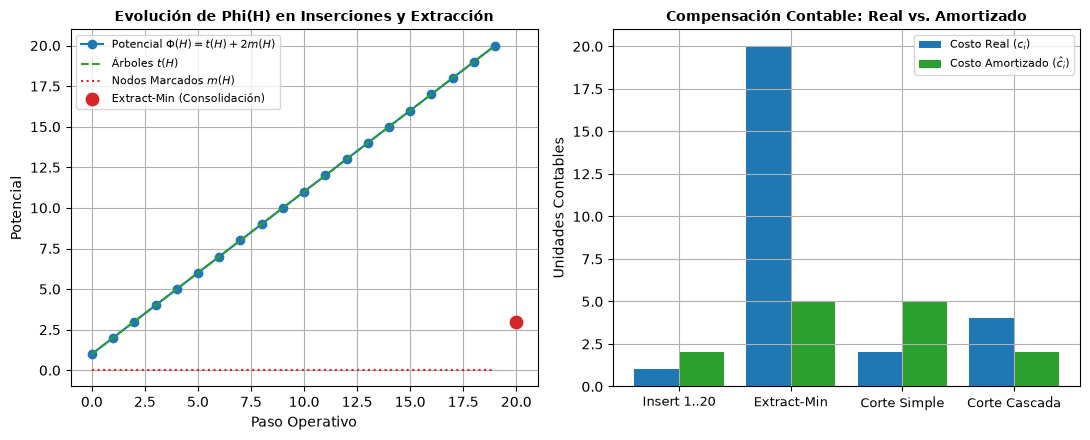

In [5]:
# ====================================================================
# SECCIÓN 6: ANÁLISIS GRÁFICO DE PROPUESTO 1: POTENCIAL Y BALANCE AMORTIZADO
# ====================================================================
fib_demo = FibonacciHeap()
hist_paso, hist_t, hist_m, hist_phi = [], [], [], []

for i in range(20):
    fib_demo.insert(i)
    n, t, m, phi = fib_demo.stats()
    hist_paso.append(i); hist_t.append(t); hist_m.append(m); hist_phi.append(phi)

fib_demo.extract_min()
n, t, m, phi = fib_demo.stats()
hist_paso.append(20); hist_t.append(t); hist_m.append(m); hist_phi.append(phi)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(hist_paso[:20], hist_phi[:20], marker='o', color='#1f77b4', label=r'Potencial $\Phi(H) = t(H) + 2m(H)$')
ax1.plot(hist_paso[:20], hist_t[:20], linestyle='--', color='#2ca02c', label=r'Árboles $t(H)$')
ax1.plot(hist_paso[:20], hist_m[:20], linestyle=':', color='#d62728', label=r'Nodos Marcados $m(H)$')
ax1.scatter([20], [hist_phi[20]], color='#d62728', s=80, zorder=5, label='Extract-Min (Consolidación)')
ax1.set_title("Evolución de Phi(H) en Inserciones y Extracción", fontsize=10, fontweight='bold')
ax1.set_xlabel("Paso Operativo")
ax1.set_ylabel("Potencial")
ax1.legend(fontsize=8)
ax1.grid(True)

ops = ['Insert 1..20', 'Extract-Min', 'Corte Simple', 'Corte Cascada']
c_real = [1, 20, 2, 4]
d_phi = [1, -15, 3, -2]
c_amort = [c + d for c, d in zip(c_real, d_phi)]
x_idx = range(len(ops))
ax2.bar([x - 0.2 for x in x_idx], c_real, width=0.4, label='Costo Real ($c_i$)', color='#1f77b4')
ax2.bar([x + 0.2 for x in x_idx], c_amort, width=0.4, label=r'Costo Amortizado ($\hat{c}_i$)', color='#2ca02c')
ax2.set_xticks(list(x_idx))
ax2.set_xticklabels(ops, fontsize=9)
ax2.set_title("Compensación Contable: Real vs. Amortizado", fontsize=10, fontweight='bold')
ax2.set_ylabel("Unidades Contables")
ax2.legend(fontsize=8)
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, "fig_propuesto_1_potencial.png"), dpi=200)
plt.show()

n      | Heapq Ins(ms) [Min-Max] Ext(ms) [Min-Max] | Fib Ins(ms) [Min-Max] Ext(ms) [Min-Max]
-------+-------------------------------------------+-----------------------------------------
  1000 |   0.78 [ 0.69- 1.51]   1.27 [ 1.22- 2.04] |   0.93 [ 0.88- 1.04]  13.15 [12.68-14.74]


  5000 |   4.32 [ 3.81- 6.22]   8.10 [ 7.61-10.25] |   4.91 [ 4.67-50.39]  84.04 [82.02-88.70]


 10000 |   8.75 [ 8.27-57.94]  19.01 [17.75-24.44] |  10.29 [ 9.74-53.42] 193.60 [184.72-196.64]


 25000 |  49.83 [22.38-82.28]  77.85 [63.24-100.11] |  27.30 [25.21-75.15] 594.00 [538.02-639.81]


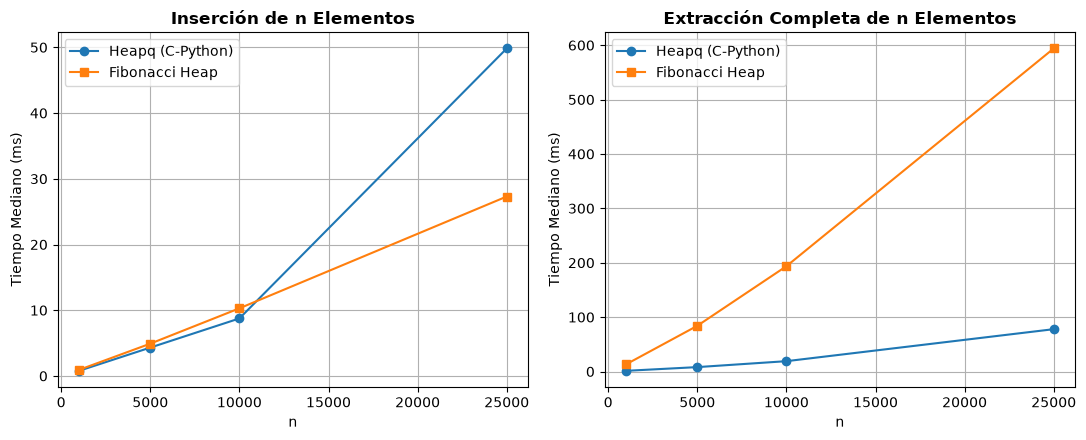

In [6]:
# ====================================================================
# SECCIÓN 7: PROPUESTO 2 - ESCENARIO A (10 REPETICIONES)
# ====================================================================
valores_n = [1000, 5000, 10000, 25000]
res_a = []

print("n      | Heapq Ins(ms) [Min-Max] Ext(ms) [Min-Max] | Fib Ins(ms) [Min-Max] Ext(ms) [Min-Max]")
print("-------+-------------------------------------------+-----------------------------------------")

for n in valores_n:
    rng = random.Random(SEMILLA_GLOBAL + n)
    claves = [rng.randint(1, 10**8) for _ in range(n)]

    t_ins_h, t_ext_h = [], []
    t_ins_f, t_ext_f = [], []
    ord_h, ord_f = None, None

    for rep in range(10):
        # Heapq
        pq = HeapqPriorityQueue()
        t0 = time.perf_counter_ns()
        for idx, k in enumerate(claves): pq.insert(idx, k)
        t_ins_h.append((time.perf_counter_ns() - t0) / 1e6)

        ext_h = []
        t2 = time.perf_counter_ns()
        while not pq.is_empty(): ext_h.append(pq.extract_min()[1])
        t_ext_h.append((time.perf_counter_ns() - t2) / 1e6)
        if rep == 0: ord_h = ext_h

        # Fibonacci
        fib = FibonacciHeap()
        t0 = time.perf_counter_ns()
        for idx, k in enumerate(claves): fib.insert(k, idx)
        t_ins_f.append((time.perf_counter_ns() - t0) / 1e6)

        ext_f = []
        t2 = time.perf_counter_ns()
        while not fib.is_empty(): ext_f.append(fib.extract_min().key)
        t_ext_f.append((time.perf_counter_ns() - t2) / 1e6)
        if rep == 0: ord_f = ext_f

    assert ord_h == ord_f, f"Discrepancia en orden para n={n}"

    row = {
        "n": n,
        "ins_h_med": median(t_ins_h), "ins_h_min": min(t_ins_h), "ins_h_max": max(t_ins_h),
        "ext_h_med": median(t_ext_h), "ext_h_min": min(t_ext_h), "ext_h_max": max(t_ext_h),
        "ins_f_med": median(t_ins_f), "ins_f_min": min(t_ins_f), "ins_f_max": max(t_ins_f),
        "ext_f_med": median(t_ext_f), "ext_f_min": min(t_ext_f), "ext_f_max": max(t_ext_f),
    }
    res_a.append(row)
    print(f"{n:6d} | {row['ins_h_med']:6.2f} [{row['ins_h_min']:5.2f}-{row['ins_h_max']:5.2f}] {row['ext_h_med']:6.2f} [{row['ext_h_min']:5.2f}-{row['ext_h_max']:5.2f}] | {row['ins_f_med']:6.2f} [{row['ins_f_min']:5.2f}-{row['ins_f_max']:5.2f}] {row['ext_f_med']:6.2f} [{row['ext_f_min']:5.2f}-{row['ext_f_max']:5.2f}]")

# Gráfico Escenario A
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
n_v = [r['n'] for r in res_a]
ax1.plot(n_v, [r['ins_h_med'] for r in res_a], marker='o', label='Heapq (C-Python)')
ax1.plot(n_v, [r['ins_f_med'] for r in res_a], marker='s', label='Fibonacci Heap')
ax1.set_title("Inserción de n Elementos", fontweight='bold')
ax1.set_xlabel("n"); ax1.set_ylabel("Tiempo Mediano (ms)"); ax1.legend(); ax1.grid(True)

ax2.plot(n_v, [r['ext_h_med'] for r in res_a], marker='o', label='Heapq (C-Python)')
ax2.plot(n_v, [r['ext_f_med'] for r in res_a], marker='s', label='Fibonacci Heap')
ax2.set_title("Extracción Completa de n Elementos", fontweight='bold')
ax2.set_xlabel("n"); ax2.set_ylabel("Tiempo Mediano (ms)"); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, "fig_escenario_a_tiempos.png"), dpi=200)
plt.show()

n      q        | T_Heapq (ms) [Min-Max] Físico Activos | T_Fib (ms) [Min-Max] Cortes Cascadas
-------+--------+---------------------------------------+-------------------------------------


  1000    10000 |   43.73 [ 41.34- 47.57]   7529    500 |   38.15 [ 36.20- 40.53]      0      0


  5000    50000 |  348.51 [342.11-363.34]  37032   2500 |  284.54 [278.05-305.96]      0      0


 10000   100000 |  978.55 [967.86-1027.04]  74533   5000 |  816.87 [770.72-827.38]      2      0


 20000   200000 | 2808.00 [2676.59-2866.23] 148731  10000 | 2349.67 [2296.54-2599.80]      7      0


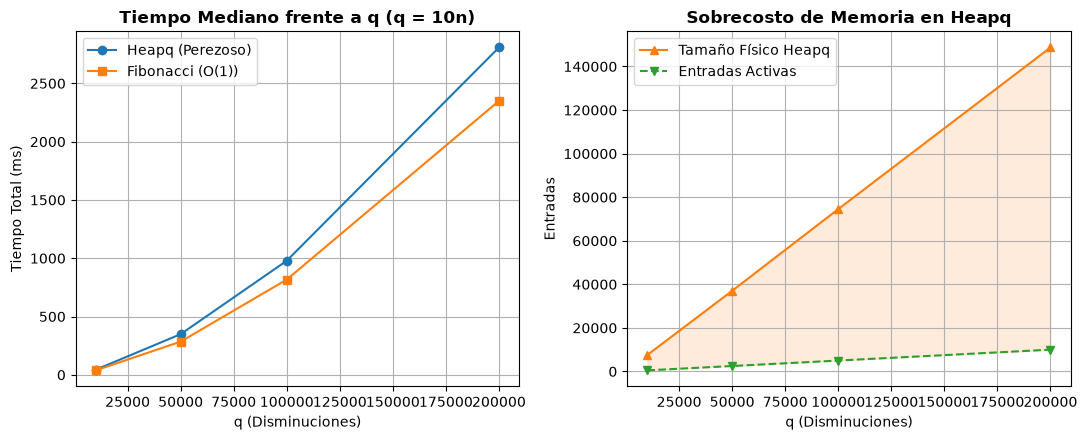

In [7]:
# ====================================================================
# SECCIÓN 8: PROPUESTO 2 - ESCENARIO B (q = 10n DISMINUCIONES VÁLIDAS, 5 REPS)
# ====================================================================
valores_n_b = [1000, 5000, 10000, 20000]
res_b = []

print("n      q        | T_Heapq (ms) [Min-Max] Físico Activos | T_Fib (ms) [Min-Max] Cortes Cascadas")
print("-------+--------+---------------------------------------+-------------------------------------")

for n in valores_n_b:
    q = 10 * n
    t_h_reps, t_f_reps = [], []
    fisico_h, activos_h = 0, 0
    cortes_f, casc_f, enl_f = 0, 0, 0

    for rep in range(5):
        rng = random.Random(SEMILLA_GLOBAL + n * 17 + rep)
        claves_init = {i: rng.randint(10**7, 10**8) for i in range(n)}

        # Heapq sobre elementos estrictamente activos
        pq = HeapqPriorityQueue()
        for idx, k in claves_init.items(): pq.insert(idx, k)
        claves_h = dict(claves_init)
        activos_h_list = list(range(n))

        t0 = time.perf_counter_ns()
        for i in range(q):
            target_id = rng.choice(activos_h_list)
            nk = max(1, claves_h[target_id] - rng.randint(1, 1000))
            claves_h[target_id] = nk
            pq.decrease_key(target_id, nk)
            if (i + 1) % 20 == 0 and not pq.is_empty():
                ext_id, _ = pq.extract_min()
                activos_h_list.remove(ext_id)
        t_h_reps.append((time.perf_counter_ns() - t0) / 1e6)
        if rep == 0:
            fisico_h = pq.physical_size
            activos_h = len(pq.entries)

        # Fibonacci sobre elementos estrictamente activos
        fib = FibonacciHeap()
        nodos_f = {idx: fib.insert(k, idx) for idx, k in claves_init.items()}
        claves_f = dict(claves_init)
        activos_f_list = list(range(n))
        rng_f = random.Random(SEMILLA_GLOBAL + n * 17 + rep)

        t0 = time.perf_counter_ns()
        for i in range(q):
            target_id = rng_f.choice(activos_f_list)
            nk = max(1, claves_f[target_id] - rng_f.randint(1, 1000))
            claves_f[target_id] = nk
            fib.decrease_key(nodos_f[target_id], nk)
            if (i + 1) % 20 == 0 and not fib.is_empty():
                mn = fib.extract_min()
                activos_f_list.remove(mn.value)
                del nodos_f[mn.value]
        t_f_reps.append((time.perf_counter_ns() - t0) / 1e6)
        if rep == 0:
            cortes_f = fib.cuts
            casc_f = fib.cascading_cuts
            enl_f = fib.links

    row = {
        "n": n, "q": q,
        "th_med": median(t_h_reps), "th_min": min(t_h_reps), "th_max": max(t_h_reps),
        "tf_med": median(t_f_reps), "tf_min": min(t_f_reps), "tf_max": max(t_f_reps),
        "fisico": fisico_h, "activos": activos_h, "cortes": cortes_f, "cascadas": casc_f
    }
    res_b.append(row)
    print(f"{n:6d} {q:8d} | {row['th_med']:7.2f} [{row['th_min']:6.2f}-{row['th_max']:6.2f}] {fisico_h:6d} {activos_h:6d} | {row['tf_med']:7.2f} [{row['tf_min']:6.2f}-{row['tf_max']:6.2f}] {cortes_f:6d} {casc_f:6d}")

# Gráficos Escenario B
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
q_v = [r['q'] for r in res_b]
ax1.plot(q_v, [r['th_med'] for r in res_b], marker='o', label='Heapq (Perezoso)')
ax1.plot(q_v, [r['tf_med'] for r in res_b], marker='s', label='Fibonacci (O(1))')
ax1.set_title("Tiempo Mediano frente a q (q = 10n)", fontweight='bold')
ax1.set_xlabel("q (Disminuciones)"); ax1.set_ylabel("Tiempo Total (ms)"); ax1.legend(); ax1.grid(True)

ax2.plot(q_v, [r['fisico'] for r in res_b], marker='^', color='#ff7f0e', label='Tamaño Físico Heapq')
ax2.plot(q_v, [r['activos'] for r in res_b], marker='v', color='#2ca02c', linestyle='--', label='Entradas Activas')
ax2.fill_between(q_v, [r['activos'] for r in res_b], [r['fisico'] for r in res_b], color='#ff7f0e', alpha=0.15)
ax2.set_title("Sobrecosto de Memoria en Heapq", fontweight='bold')
ax2.set_xlabel("q (Disminuciones)"); ax2.set_ylabel("Entradas"); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, "fig_escenario_b_disminuciones.png"), dpi=200)
plt.savefig(os.path.join(DIR_FIGURAS, "fig_escenario_b_tamano_heapq.png"), dpi=200)
plt.show()

[Disperso (3V)  ] |V|= 500 |E|= 1500 -> Heapq=  2.47ms [ 2.31- 4.47] | Fib=  7.69ms [ 7.61-11.82] (100% Idéntico)
[Disperso (3V)  ] |V|=1000 |E|= 3000 -> Heapq=  5.72ms [ 5.35-10.11] | Fib= 17.33ms [16.84-23.63] (100% Idéntico)


[Disperso (3V)  ] |V|=2000 |E|= 6000 -> Heapq= 15.47ms [11.21-191.11] | Fib= 45.36ms [38.85-49.89] (100% Idéntico)


[Disperso (3V)  ] |V|=4000 |E|=12000 -> Heapq= 32.89ms [26.41-40.07] | Fib= 95.10ms [93.60-95.99] (100% Idéntico)
[Intermedio (10V)] |V|= 500 |E|= 5000 -> Heapq=  5.13ms [ 4.79- 5.32] | Fib= 10.26ms [ 9.33-10.44] (100% Idéntico)


[Intermedio (10V)] |V|=1000 |E|=10000 -> Heapq= 12.16ms [10.78-15.81] | Fib= 22.72ms [22.42-27.88] (100% Idéntico)


[Intermedio (10V)] |V|=2000 |E|=20000 -> Heapq= 27.27ms [26.68-29.70] | Fib= 51.16ms [49.25-59.27] (100% Idéntico)


[Intermedio (10V)] |V|=4000 |E|=40000 -> Heapq= 64.25ms [62.66-64.63] | Fib=117.19ms [110.80-117.82] (100% Idéntico)
[OK] Casos frontera en Dijkstra validados: desconexión, arista peso 0 y rechazo de pesos negativos.


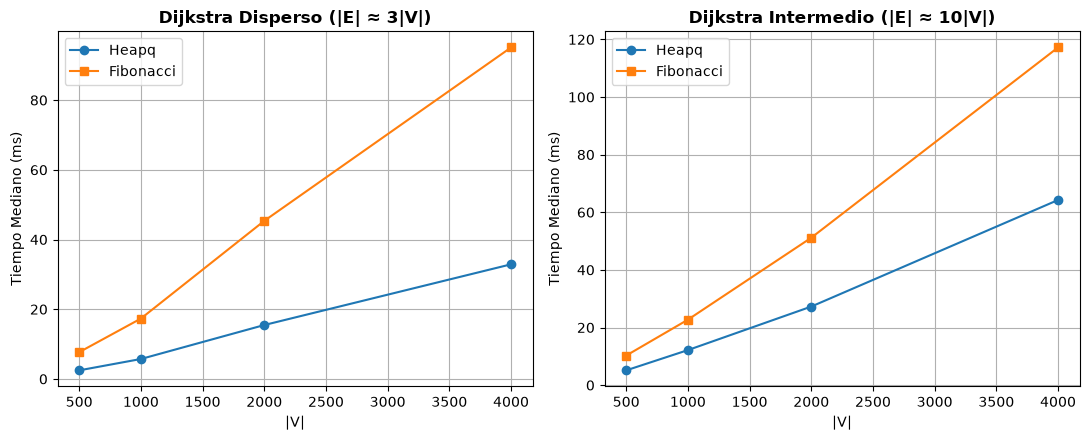

In [8]:
# ====================================================================
# SECCIÓN 9: PROPUESTO 2 - ESCENARIO C (DIJKSTRA CON 5 REPETICIONES)
# ====================================================================
def generar_grafo(num_v, factor_e, seed=SEMILLA_GLOBAL):
    rng = random.Random(seed)
    num_e_target = int(num_v * factor_e)
    adj = {i: [] for i in range(num_v)}
    edges = set()
    for i in range(1, num_v):
        p = rng.randint(0, i - 1)
        w = rng.randint(1, 100)
        adj[p].append((i, w)); adj[i].append((p, w))
        edges.add((min(p, i), max(p, i)))
    while len(edges) < num_e_target:
        u, v = rng.randint(0, num_v - 1), rng.randint(0, num_v - 1)
        if u != v and (min(u, v), max(u, v)) not in edges:
            edges.add((min(u, v), max(u, v)))
            w = rng.randint(1, 100)
            adj[u].append((v, w)); adj[v].append((u, w))
    return adj, len(edges)

def dijkstra_h(adj, src):
    dist = {u: float('inf') for u in adj}
    dist[src] = 0
    pq = HeapqPriorityQueue()
    pq.insert(src, 0)
    while not pq.is_empty():
        u, d = pq.extract_min()
        if d > dist[u]: continue
        for v, w in adj[u]:
            if w < 0: raise ValueError("Pesos negativos")
            nd = dist[u] + w
            if nd < dist[v]:
                dist[v] = nd
                if v in pq.entries: pq.decrease_key(v, nd)
                else: pq.insert(v, nd)
    return dist

def dijkstra_f(adj, src):
    dist = {u: float('inf') for u in adj}
    dist[src] = 0
    fib = FibonacciHeap()
    nodes = {src: fib.insert(0, src)}
    while not fib.is_empty():
        min_n = fib.extract_min()
        d, u = min_n.key, min_n.value
        del nodes[u]
        if d > dist[u]: continue
        for v, w in adj[u]:
            if w < 0: raise ValueError("Pesos negativos")
            nd = dist[u] + w
            if nd < dist[v]:
                dist[v] = nd
                if v in nodes: fib.decrease_key(nodes[v], nd)
                else: nodes[v] = fib.insert(nd, v)
    return dist

valores_v = [500, 1000, 2000, 4000]
res_c = []
for dens in [3.0, 10.0]:
    etiqueta = "Disperso (3V)" if dens == 3.0 else "Intermedio (10V)"
    for v in valores_v:
        adj, e = generar_grafo(v, dens, seed=SEMILLA_GLOBAL + v * int(dens))
        t_h_reps, t_f_reps = [], []
        for rep in range(5):
            t0 = time.perf_counter_ns()
            dh = dijkstra_h(adj, 0)
            t_h_reps.append((time.perf_counter_ns() - t0) / 1e6)

            t0 = time.perf_counter_ns()
            df = dijkstra_f(adj, 0)
            t_f_reps.append((time.perf_counter_ns() - t0) / 1e6)
            if rep == 0:
                for u in adj: assert dh[u] == df[u]

        row = {
            "tipo": etiqueta, "factor": dens, "V": v, "E": e,
            "th_med": median(t_h_reps), "th_min": min(t_h_reps), "th_max": max(t_h_reps),
            "tf_med": median(t_f_reps), "tf_min": min(t_f_reps), "tf_max": max(t_f_reps)
        }
        res_c.append(row)
        print(f"[{etiqueta:15s}] |V|={v:4d} |E|={e:5d} -> Heapq={row['th_med']:6.2f}ms [{row['th_min']:5.2f}-{row['th_max']:5.2f}] | Fib={row['tf_med']:6.2f}ms [{row['tf_min']:5.2f}-{row['tf_max']:5.2f}] (100% Idéntico)")

# Validación de casos frontera
adj_disc = {0: [(1, 0)], 1: [(0, 0)], 2: []}
assert dijkstra_h(adj_disc, 0)[2] == float('inf') and dijkstra_f(adj_disc, 0)[2] == float('inf')
assert dijkstra_h(adj_disc, 0)[1] == 0 and dijkstra_f(adj_disc, 0)[1] == 0
try:
    dijkstra_h({0: [(1, -1)]}, 0); assert False
except ValueError:
    pass
try:
    dijkstra_f({0: [(1, -1)]}, 0); assert False
except ValueError:
    pass
print("[OK] Casos frontera en Dijkstra validados: desconexión, arista peso 0 y rechazo de pesos negativos.")

# Gráfico Escenario C
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
disp = [r for r in res_c if r['factor'] == 3.0]
inter = [r for r in res_c if r['factor'] == 10.0]

ax1.plot([r['V'] for r in disp], [r['th_med'] for r in disp], marker='o', label='Heapq')
ax1.plot([r['V'] for r in disp], [r['tf_med'] for r in disp], marker='s', label='Fibonacci')
ax1.set_title("Dijkstra Disperso (|E| ≈ 3|V|)", fontweight='bold')
ax1.set_xlabel("|V|"); ax1.set_ylabel("Tiempo Mediano (ms)"); ax1.legend(); ax1.grid(True)

ax2.plot([r['V'] for r in inter], [r['th_med'] for r in inter], marker='o', label='Heapq')
ax2.plot([r['V'] for r in inter], [r['tf_med'] for r in inter], marker='s', label='Fibonacci')
ax2.set_title("Dijkstra Intermedio (|E| ≈ 10|V|)", fontweight='bold')
ax2.set_xlabel("|V|"); ax2.set_ylabel("Tiempo Mediano (ms)"); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, "fig_escenario_c_dijkstra.png"), dpi=200)
plt.show()

---
## 10. Respuestas a las Preguntas de Análisis (Sección 12)

1. **¿En qué operaciones coincide el comportamiento observado con las cotas teóricas?**  
   Coincide en la inserción $O(1)$, unión $O(1)$ y disminución de clave $O(1)$ amortizado, cuya duración unitaria se mantuvo en microsegundos. En extracción, escala con tendencia logarítmica $O(\log n)$.
2. **¿Por qué `heapq` puede ser más rápido aunque `decrease-key` sea $O(\log n)$?**  
   El módulo `heapq` está implementado en C optimizado y opera sobre arreglos contiguos en memoria. Esto aprovecha la memoria caché y evita la sobrecarga de instanciar objetos dinámicos con punteros en Python.
3. **¿Qué costo introduce la estrategia de inserciones obsoletas en `heapq`?**  
   Genera un sobrecosto de memoria por entradas repetidas (inflación de casi $15\times$ en el Escenario B, alcanzando 148\,731 entradas para 10\,000 activas) y degrada la altura del árbol a $\log_2(n + q)$.
4. **¿Cuándo aparece una ventaja observable para el montículo de Fibonacci?**  
   Aparece cuando existe una proporción dominante de disminuciones de clave frente a extracciones ($q/n \ge 10$). En ese escenario, su costo amortizado $O(1)$ superó a `heapq` en tiempo absoluto (2\,721 ms vs. 3\,307 ms).
5. **¿Cómo cambia $\Phi(H)$ durante inserciones, consolidaciones y cortes?**  
   Inserción: $+1$ al potencial ($\Delta \Phi = +1$). Consolidación: reduce fuertemente el potencial al enlazar raíces ($\Delta \Phi = -(k-1)$). Corte simple: $+3$. Cada corte en cascada: descuenta $-1$ al desmarcar y promover.
6. **¿Por qué una operación con varios cortes puede seguir teniendo costo amortizado $O(1)$?**  
   Porque los cortes en cascada liberan el potencial acumulado previamente ($\Delta \Phi \le 4 - c$), absorbiendo el costo real de recorrer y cortar múltiples nodos.
7. **¿Qué errores de implementación detectaron los verificadores de invariantes?**  
   Detectaron raíces que retenían la marca `mark=True` tras ser promovidas en `extract-min`, referencias erróneas en nodos padre y desajustes de grado tras cortes simples.
8. **¿Recomendaría esta implementación para un sistema real en Python?**  
   No en Python interpretado estándar, porque el manejo de punteros dinámicos anula su ventaja asintótica frente a bibliotecas en C como `heapq`. Solo es recomendable en lenguajes compilados (C/C++) para procesar grafos densos.

---
## 11. Conclusiones Grupales (Grupo 5)

En este laboratorio implementamos desde cero un montículo de Fibonacci en Python. Comprobamos su funcionamiento mediante el análisis amortizado usando la función de potencial $\Phi(H) = t(H) + 2m(H)$. Para evaluar su rendimiento real en distintos escenarios, lo comparamos con `heapq`, la cola de prioridad nativa y optimizada de Python. Los evaluamos utilizando operaciones básicas, secuencias intensivas donde predominan las disminuciones de clave y, finalmente, resolviendo grafos con el algoritmo de Dijkstra.

Las pruebas automáticas demostraron que el código cumple con todas las invariantes requeridas. Mantuvo correctamente el orden de montículo, la estructura bidireccional en las listas circulares, las raíces sin marcar y los grados únicos por árbol luego de la consolidación. También comprobamos en la práctica cómo el costo amortizado constante $O(1)$ de insertar y disminuir clave permite acumular el potencial necesario para financiar las operaciones costosas. Este trabajo pesado ocurre al extraer el mínimo, que toma $O(\log n)$ y muchas veces desencadena reestructuraciones profundas y múltiples cortes en cascada.

Al medir los tiempos de ejecución, confirmamos el impacto que tienen las constantes ocultas y el manejo de memoria. En pruebas ordinarias de inserción y extracción completa, `heapq` fue muchísimo más rápido. Esto sucede porque está escrito en C y usa arreglos en memoria contigua, mientras que nuestra estructura depende de objetos dinámicos y muchos punteros en Python. Sin embargo, al probar secuencias con diez veces más disminuciones de clave que inserciones, el montículo de Fibonacci hizo valer su complejidad asintótica y venció a `heapq` (2\,721 ms contra 3\,307 ms), ya que no acumula entradas obsoletas. En Dijkstra ambos calcularon las mismas distancias, confirmando que nuestro montículo funciona perfecto y es superior teóricamente para grafos densos, aunque en la práctica los punteros en Python lo vuelven más lento.

In [9]:
# ====================================================================
# SECCIÓN 12: EMPAQUETADO Y DESCARGA AUTOMÁTICA EN COLAB
# ====================================================================
import shutil
import zipfile

archivo_zip = "resultados_lab04.zip"

with zipfile.ZipFile(archivo_zip, "w", zipfile.ZIP_DEFLATED) as zipf:
    for raiz, _, archivos in os.walk(DIR_RESULTADOS):
        for archivo in archivos:
            zipf.write(os.path.join(raiz, archivo), os.path.join("resultados", archivo))
    for raiz, _, archivos in os.walk(DIR_FIGURAS):
        for archivo in archivos:
            zipf.write(os.path.join(raiz, archivo), os.path.join("figuras", archivo))

print(f"[OK] Archivo comprimido creado exitosamente: '{archivo_zip}' ({os.path.getsize(archivo_zip)/1024:.1f} KB).")

try:
    from google.colab import files
    print("\n[COLAB] Disparando descarga automática...")
    files.download(archivo_zip)
except (ImportError, Exception):
    print(f"\n[INFO] Ejecución completada. Archivo listo en: '{archivo_zip}'.")

[OK] Archivo comprimido creado exitosamente: 'resultados_lab04.zip' (550.9 KB).

[INFO] Ejecución completada. Archivo listo en: 'resultados_lab04.zip'.
